In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\Asus\Documents\skripsi-karhut\.venv\Scripts\python.exe
3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb
import pyarrow

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("duckdb:", duckdb.__version__)
print("pyarrow:", pyarrow.__version__)
print("SEMUA LIBRARY BERHASIL")

Matplotlib is building the font cache; this may take a moment.


pandas: 3.0.5
numpy: 2.5.3
duckdb: 1.5.5
pyarrow: 25.0.1
SEMUA LIBRARY BERHASIL


In [3]:
from pathlib import Path

project_root = Path.cwd().parent
raw_dir = project_root / "data" / "raw"

print("Project:", project_root)
print("Raw:", raw_dir)
print()
print("Isi raw:")
for item in raw_dir.iterdir():
    print(item)

Project: c:\Users\Asus\Documents\skripsi-karhut
Raw: c:\Users\Asus\Documents\skripsi-karhut\data\raw

Isi raw:


In [4]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent

fire_dir = (
    project_root
    / "data"
    / "raw"
    / "kalimantan"
    / "fire_firms"
    / "hourly"
)

print(fire_dir)
print("Folder exists:", fire_dir.exists())

c:\Users\Asus\Documents\skripsi-karhut\data\raw\kalimantan\fire_firms\hourly
Folder exists: True


In [5]:
from pathlib import Path

fire_files = sorted(fire_dir.glob("*.csv"))

print("Jumlah file:", len(fire_files))
print("\nFile:")
for file in fire_files:
    print("-", file.name)

Jumlah file: 5

File:
- fires_2026-09-07.csv
- fires_2026-09-08.csv
- fires_2026-09-09.csv
- fires_2026-09-10.csv
- fires_2026-09-11.csv


In [6]:
sample_file = fire_files[0]

fire_sample = pd.read_csv(sample_file)

print("File:", sample_file.name)
print("Jumlah baris:", len(fire_sample))
print("Jumlah kolom:", len(fire_sample.columns))

fire_sample.head()


File: fires_2026-09-07.csv
Jumlah baris: 1027
Jumlah kolom: 4


,time_utc,lat,lon,frp
0,2026-09-07T05:00,-3.86786,105.26985,8.44
1,2026-09-07T05:00,-3.62063,105.71695,7.17
2,2026-09-07T05:00,-3.44257,105.82496,27.19
3,2026-09-07T05:00,-3.11607,105.33743,4.48
4,2026-09-07T05:00,-3.11496,105.30244,5.95


In [7]:
print("Kolom:")
for col in fire_sample.columns:
    print("-", col)

Kolom:
- time_utc
- lat
- lon
- frp


In [8]:
fire_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 1027 entries, 0 to 1026
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time_utc  1027 non-null   str    
 1   lat       1027 non-null   float64
 2   lon       1027 non-null   float64
 3   frp       1027 non-null   float64
dtypes: float64(3), str(1)
memory usage: 48.3 KB


In [9]:
missing = fire_sample.isna().sum()

print(missing)

time_utc    0
lat         0
lon         0
frp         0
dtype: int64


In [10]:
print("\nPersentase missing:")
print((fire_sample.isna().mean() * 100).round(2))


Persentase missing:
time_utc    0.0
lat         0.0
lon         0.0
frp         0.0
dtype: float64


In [11]:
fire_sample["time_utc"] = pd.to_datetime(
    fire_sample["time_utc"],
    errors="coerce"
)

print(fire_sample["time_utc"].dtype)
print("Min:", fire_sample["time_utc"].min())
print("Max:", fire_sample["time_utc"].max())

datetime64[us]
Min: 2026-09-07 05:00:00
Max: 2026-09-07 18:00:00


In [12]:
fire_sample[["lat", "lon"]].describe()

,lat,lon
count,1027.000000,1027.000000
mean,-2.149112,104.152617
std,1.978745,1.376454
min,-5.442110,97.068970
25%,-3.292895,103.283245
50%,-2.876260,104.350200
75%,-1.768950,105.233305
max,5.649910,106.389400


In [13]:
print("Latitude:")
print(fire_sample["lat"].min(), "→", fire_sample["lat"].max())

print("\nLongitude:")
print(fire_sample["lon"].min(), "→", fire_sample["lon"].max())

Latitude:
-5.44211 → 5.64991

Longitude:
97.06897 → 106.3894


In [14]:
fire_sample["frp"].describe()

count    1027.000000
mean        5.068354
std         7.024175
min         0.180000
25%         1.180000
50%         2.290000
75%         6.115000
max        59.280000
Name: frp, dtype: float64

In [15]:
print("FRP minimum:", fire_sample["frp"].min())
print("FRP maksimum:", fire_sample["frp"].max())
print("FRP missing:", fire_sample["frp"].isna().sum())

FRP minimum: 0.18
FRP maksimum: 59.28
FRP missing: 0


In [16]:
print("Duplicate seluruh baris:", fire_sample.duplicated().sum())

Duplicate seluruh baris: 0


In [17]:
print(
    "Duplicate time + lat + lon:",
    fire_sample.duplicated(
        subset=["time_utc", "lat", "lon"]
    ).sum()
)

Duplicate time + lat + lon: 0


In [18]:
fire_sample["hour_utc"] = fire_sample["time_utc"].dt.hour

hour_counts = (
    fire_sample["hour_utc"]
    .value_counts()
    .sort_index()
)

print(hour_counts)

hour_utc
5     155
7      93
18    779
Name: count, dtype: int64


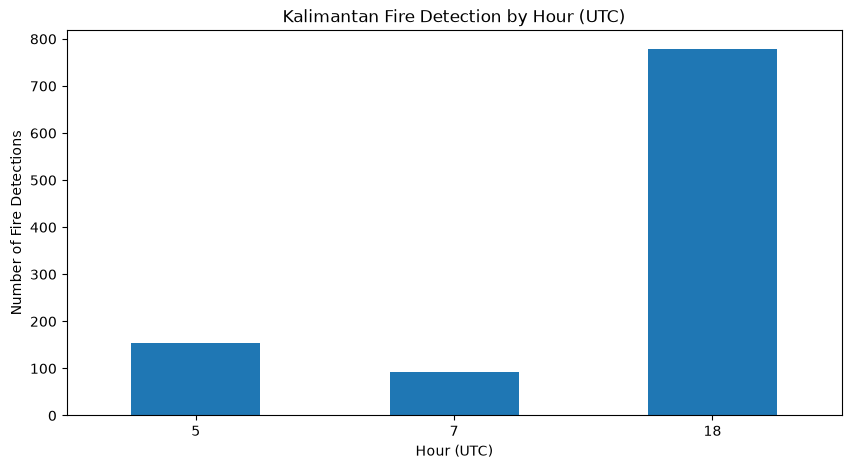

In [19]:
plt.figure(figsize=(10, 5))

hour_counts.plot(kind="bar")

plt.xlabel("Hour (UTC)")
plt.ylabel("Number of Fire Detections")
plt.title("Kalimantan Fire Detection by Hour (UTC)")
plt.xticks(rotation=0)

plt.show()

In [20]:
fire_list = []

for file in fire_files:
    temp = pd.read_csv(file)
    temp["source_file"] = file.name
    fire_list.append(temp)

fire_5days = pd.concat(
    fire_list,
    ignore_index=True
)

print("Total detections:", len(fire_5days))
print("Shape:", fire_5days.shape)

Total detections: 3546
Shape: (3546, 5)


In [21]:
fire_5days["time_utc"] = pd.to_datetime(
    fire_5days["time_utc"],
    errors="coerce"
)

In [22]:
print("Periode:")
print(fire_5days["time_utc"].min())
print(fire_5days["time_utc"].max())

Periode:
2026-09-07 05:00:00
2026-09-11 06:00:00


In [23]:
fire_5days["date"] = fire_5days["time_utc"].dt.date

In [24]:
daily_counts = (
    fire_5days
    .groupby("date")
    .size()
    .reset_index(name="n_detections")
)

daily_counts

,date,n_detections
0,2026-09-07,1027
1,2026-09-08,1010
2,2026-09-09,985
3,2026-09-10,418
4,2026-09-11,106


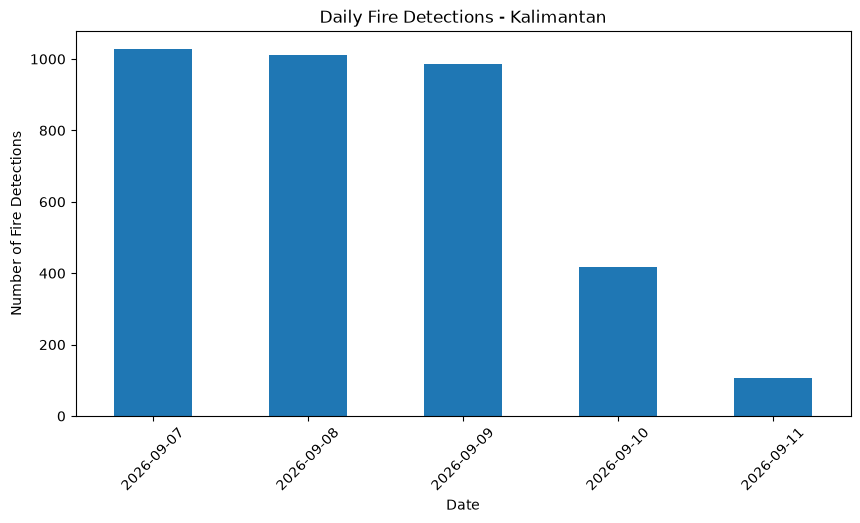

In [25]:
daily_counts.plot(
    x="date",
    y="n_detections",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.xlabel("Date")
plt.ylabel("Number of Fire Detections")
plt.title("Daily Fire Detections - Kalimantan")
plt.xticks(rotation=45)

plt.show()

In [26]:
fire_sample.head()

,time_utc,lat,lon,frp,hour_utc
0,2026-09-07 05:00:00,-3.86786,105.26985,8.44,5
1,2026-09-07 05:00:00,-3.62063,105.71695,7.17,5
2,2026-09-07 05:00:00,-3.44257,105.82496,27.19,5
3,2026-09-07 05:00:00,-3.11607,105.33743,4.48,5
4,2026-09-07 05:00:00,-3.11496,105.30244,5.95,5


In [27]:
fire_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 1027 entries, 0 to 1026
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time_utc  1027 non-null   datetime64[us]
 1   lat       1027 non-null   float64       
 2   lon       1027 non-null   float64       
 3   frp       1027 non-null   float64       
 4   hour_utc  1027 non-null   int32         
dtypes: datetime64[us](1), float64(3), int32(1)
memory usage: 36.2 KB


In [28]:
fire_sample.isna().sum()

time_utc    0
lat         0
lon         0
frp         0
hour_utc    0
dtype: int64

In [29]:
fire_sample[["lat", "lon"]].describe()

,lat,lon
count,1027.000000,1027.000000
mean,-2.149112,104.152617
std,1.978745,1.376454
min,-5.442110,97.068970
25%,-3.292895,103.283245
50%,-2.876260,104.350200
75%,-1.768950,105.233305
max,5.649910,106.389400


In [30]:
fire_sample["frp"].describe()

count    1027.000000
mean        5.068354
std         7.024175
min         0.180000
25%         1.180000
50%         2.290000
75%         6.115000
max        59.280000
Name: frp, dtype: float64

In [31]:
fire_sample["hour_utc"] = fire_sample["time_utc"].dt.hour

In [32]:
hour_counts = (
    fire_sample["hour_utc"]
    .value_counts()
    .sort_index()
)

print(hour_counts)

hour_utc
5     155
7      93
18    779
Name: count, dtype: int64


In [33]:
fire_5days["date"] = fire_5days["time_utc"].dt.date

In [35]:
daily_counts = (
    fire_5days
    .groupby("date")
    .size()
    .reset_index(name="n_detections")
)

daily_counts

,date,n_detections
0,2026-09-07,1027
1,2026-09-08,1010
2,2026-09-09,985
3,2026-09-10,418
4,2026-09-11,106
